Make a discrete time state space model with 3 hiddenstates and we observe the first two hidden states. 

In [6]:
# --- Setup / imports ---
import jax
import jax.numpy as jnp
import jax.random as random

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import arviz as az
import matplotlib.pyplot as plt

# Reproducible RNG key (JAX handles randomness explicitly via keys)
rng_key = random.PRNGKey(0)

print("jax       ", jax.__version__)
print("numpyro   ", numpyro.__version__)
print("arviz     ", az.__version__)
print("Setup OK — kernel is working.")

jax        0.9.2
numpyro    0.21.0
arviz      0.23.4
Setup OK — kernel is working.


In [8]:
import jax.numpy as jnp
import dynestyx as dsx

from dynestyx.models import DynamicalModel  # noqa: F811

# for convenience, we can define "fixed" things in the model outside of it.
# this is not required, but it helps keep the model clean.
state_dim = 3
observation_dim = 2
control_dim = 2

# Create the known matrices B, C
B = jnp.eye(state_dim, control_dim)
C = jnp.eye(observation_dim, state_dim)

# create the initial condition as a distribution
initial_condition = dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim))

# create the observation model as a callable mapping to a distribution
observation_model = lambda x, u, t: dist.MultivariateNormal(
    C @ x, 0.1**2 * jnp.eye(observation_dim)
)


def lti_model(rho=None, theta=None, obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None, predict_times=None):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.5, 0.5), obs=rho)
    theta = numpyro.sample("theta", dist.Uniform(-0.5, 0.5), obs=theta)
    A = jnp.array([[0, 0.3, 0.5], [rho, -0.2, 0.7], [-0.6, theta, 0.4]])

    # create the state evolution as a callable mapping to a distribution
    # Crucially, this depends on A, which depends on rho, which is unknown.
    # Thus, the state evolution MUST be defined within `lti_model`, not outside.
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(
        A @ x + B @ u, 0.1**2 * jnp.eye(state_dim)
    )

    # create the dynamical model
    dynamics = DynamicalModel(
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

    # sample from the dynamical model
    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values, predict_times=predict_times)

Generate Data with the Predictive Object

In [15]:

import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import flatten_draws
from dynestyx import DiscreteTimeSimulator, DynamicalModel


# Generate longer trajectory: training portion + held-out future for rollout evaluation
n_train = 150
T_forecast = 150
obs_times_full = jnp.arange(0.0, n_train + T_forecast + 1, 1.0)
ctrl_times_full = obs_times_full
ctrl_values_full = jr.normal(jr.PRNGKey(0), (len(ctrl_times_full), control_dim))

# Train / test split
obs_times = obs_times_full[:n_train]
obs_times_test = obs_times_full[n_train:]
ctrl_times = ctrl_times_full[:n_train]
ctrl_times_test = ctrl_times_full[n_train:]
ctrl_values = ctrl_values_full[:n_train]
ctrl_values_test = ctrl_values_full[n_train:]

rho_true = 0.3
theta_true = -0.3


# For an autonomous system, we would simply omit ctrl_times and ctrl_values.
# Specifying rho_true means we are generating real data

with DiscreteTimeSimulator():
    predictive = Predictive(
        lti_model,
        params={"rho": jnp.array(rho_true), "theta": jnp.array(theta_true)},
        num_samples=1,
        exclude_deterministic=False,
    )

    pred = predictive(rng_key=jr.PRNGKey(0), predict_times=obs_times_full, ctrl_times=ctrl_times_full, ctrl_values=ctrl_values_full)

print(pred.keys())
print("Predicted states shape:", pred["f_states"].shape)
print("Predicted observations shape:", pred["f_observations"].shape)
print("Predicted times shape:", pred["f_times"].shape)


obs = pred["f_observations"][0, 0, :, :]
states = pred["f_states"][0, 0, :, :]
obs_values = obs[:n_train]
obs_values_test = obs[n_train:]
states_train = states[:n_train]
states_test = states[n_train:]


dict_keys(['f_observations', 'f_states', 'f_times', 'f_x_0', 'f_x_JitTracer(int32[])', 'f_y_0', 'f_y_JitTracer(int32[])', 'rho', 'theta'])
Predicted states shape: (1, 1, 301, 3)
Predicted observations shape: (1, 1, 301, 2)
Predicted times shape: (1, 1, 301)


Run MCMC

In [16]:
from dynestyx import Filter
from numpyro.infer import MCMC, NUTS
from dynestyx.inference.filters import EKFConfig
# Pseudo-marginal inference (record filtered states for latent recovery plot)

with Filter(filter_config=EKFConfig()):
    nuts_kernel = NUTS(lti_model)
    mcmc = MCMC(nuts_kernel, num_warmup=150, num_samples=150)
    mcmc.run(jr.PRNGKey(1), obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values)
    posterior_1 = mcmc.get_samples()

# Joint state + parameter inference
with DiscreteTimeSimulator():
    nuts_kernel = NUTS(lti_model)
    mcmc = MCMC(nuts_kernel, num_warmup=150, num_samples=150)
    mcmc.run(jr.PRNGKey(1), obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values)
    posterior_2 = mcmc.get_samples()

sample: 100%|██████████| 300/300 [00:00<00:00, 430.09it/s, 15 steps of size 2.78e-01. acc. prob=0.83]


Plot Posteriors

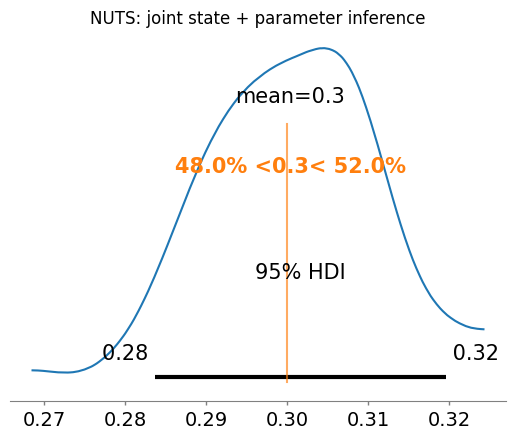

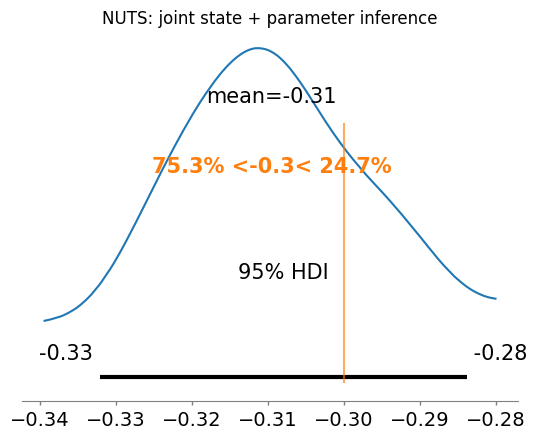

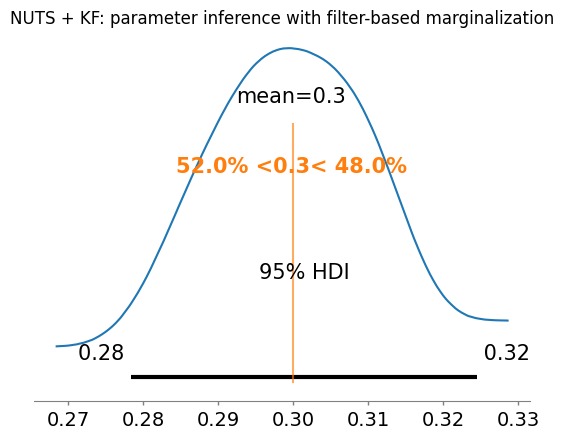

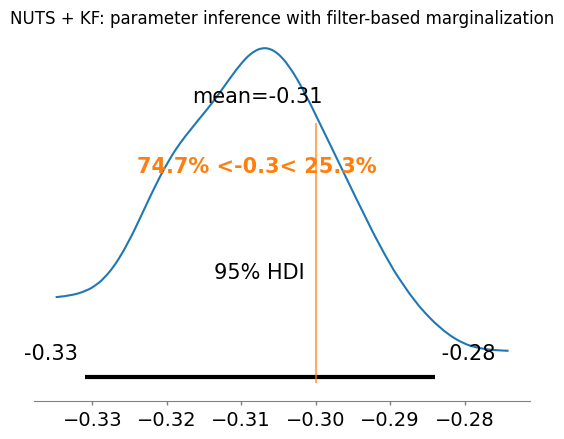

In [18]:
import arviz as az
import matplotlib.pyplot as plt

az.plot_posterior(posterior_1["rho"], hdi_prob=0.95, ref_val=rho_true)
plt.title("NUTS: joint state + parameter inference")

az.plot_posterior(posterior_1["theta"], hdi_prob=0.95, ref_val=theta_true)
plt.title("NUTS: joint state + parameter inference")

az.plot_posterior(posterior_2["rho"], hdi_prob=0.95, ref_val=rho_true)
plt.title("NUTS + KF: parameter inference with filter-based marginalization")

az.plot_posterior(posterior_2["theta"], hdi_prob=0.95, ref_val=theta_true)
plt.title("NUTS + KF: parameter inference with filter-based marginalization")
plt.show()

Latent State Recovery

In [ ]:
# Latent state recovery: 1 plot for MCMC (joint), 1 for marginal MCMC
# Observed component = first state (C = [1, 0]); overlay data as scatter there.

def plot_latent_recovery(states_samples, title, obs_times, obs_values, state_dim=3):
    """states_samples: (num_samples, T, state_dim). One figure, one subplot per state component."""
    n_comp = state_dim
    mean_states = states_samples.mean(axis=0)  # (T, state_dim)
    lo = jnp.percentile(states_samples, 2.5, axis=0)
    hi = jnp.percentile(states_samples, 97.5, axis=0)
    fig, axes = plt.subplots(
        n_comp, 1, figsize=(7, 2.5 * n_comp), sharex=True, constrained_layout=True
    )
    if n_comp == 1:
        axes = [axes]
    for i in range(n_comp):
        ax = axes[i]
        ax.fill_between(obs_times, lo[:, i], hi[:, i], alpha=0.3)
        ax.plot(obs_times, mean_states[:, i], label=f"x{i} (mean)")
        if i < observation_dim:  # observed components: overlay data
            ax.scatter(
                obs_times,
                obs_values[:, i],
                s=8,
                alpha=0.7,
                color="k",
                label="observations",
                zorder=3,
            )
        ax.set_ylabel(f"x{i}")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("time")
    fig.suptitle(title)
    plt.show()


# MCMC (joint): posterior over states from simulator.
# f_states has shape (num_samples, n_sim, T, state_dim); flatten_draws merges the draw axes.
states_joint = flatten_draws(posterior_2["f_states"])
plot_latent_recovery(
    states_joint,
    "Latent state recovery — MCMC (joint state + parameter)",
    obs_times,
    obs_values,
    state_dim=state_dim,
)

# Pseudo-marginal MCMC: filtered state means from KF (one per rho sample).
# f_filtered_states_mean has shape (num_samples, T, state_dim) — no n_sim axis from filter.
plot_latent_recovery(
    posterior_1["f_filtered_states_mean"],
    "Latent state recovery — pseudo-marginal MCMC (filter)",
    obs_times,
    obs_values,
    state_dim=state_dim,
)

Evaluating Rollout Quality by Forecasting

In [ ]:
from numpyro.infer import Predictive

from dynestyx import Filter, flatten_draws
from dynestyx.inference.filter_configs import EKFConfig


# Use posterior mean for rollout
rho_post_mean = jnp.mean(posterior_2["rho"])
theta_post_mean = jnp.mean(posterior_2["theta"])
n_sim = 20
num_samples = 2  # Use sequential loop to avoid lax.map overhead

predictive = Predictive(
    lti_model,
    params={"rho": jnp.array(rho_post_mean), "theta": jnp.array(theta_post_mean)},
    num_samples=num_samples,
    exclude_deterministic=False,
)

with DiscreteTimeSimulator(n_simulations=n_sim):
    with Filter(filter_config=EKFConfig(record_filtered_states_mean=True, filter_source="cuthbert")):
        samples = predictive(
            jr.PRNGKey(99),
            obs_times=obs_times,
            obs_values=obs_values,
            ctrl_times=ctrl_times_full,
            ctrl_values=ctrl_values_full,
            predict_times=obs_times_test,
        )

pred_states = jnp.asarray(samples["f_predicted_states"])  # (num_samples, n_sim, T_pred, state_dim)
pred_times_arr = jnp.asarray(samples["f_predicted_times"])  # (num_samples, n_sim, T_pred)
filtered_means = jnp.asarray(samples["f_filtered_states_mean"])  # (num_samples, T_train, state_dim)

print("rollout shapes:", pred_states.shape, pred_times_arr.shape, filtered_means.shape)

# flatten_draws merges (num_samples, n_sim, T, D) → (num_samples*n_sim, T, D).
# Filter outputs like f_filtered_states_mean are already (num_samples, T, D) with no n_sim axis.
pred_draws = flatten_draws(pred_states)
pred_t = flatten_draws(pred_times_arr)[0]
filtered_med = jnp.percentile(filtered_means, 50.0, axis=0)

# Plot: true states, filtered means, observations, predicted CI — all 3 hidden states
fig, axes = plt.subplots(state_dim, 1, figsize=(10, 2.5 * state_dim), sharex=True)
lo = jnp.percentile(pred_draws, 2.5, axis=0)
hi = jnp.percentile(pred_draws, 97.5, axis=0)
for i, ax in enumerate(axes):
    ax.fill_between(pred_t, lo[:, i], hi[:, i], alpha=0.3, label="95% CI (rollout)")
    ax.plot(obs_times, states_train[:, i], "k--", label="True (train)", lw=1)
    ax.plot(obs_times_test, states_test[:, i], "k:", lw=1.5, label="True (test, held-out)")
    ax.plot(obs_times, filtered_med[:, i], "g.-", markersize=3, label="Filtered")
    if i < observation_dim:  # observed components: overlay data
        ax.scatter(obs_times, obs_values[:, i], color="C3", marker="x", s=20, label="Observed")
    ax.set_ylabel(f"$x_{i}$")
    ax.axvline(obs_times[-1], color="gray", linestyle=":", alpha=0.7)
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_title("Filter + DiscreteTimeSimulator: rollout with predict_times")
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()